# Comparison of filters: KF, UFK and PF in three models

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath(".."))

from Filters.kalman import KalmanFilter
from Filters.ukf import UnscentedKalmanFilter
from Filters.particle import ParticleFilter
from Filters.ukf_pf import UKF_PF

from Models.linear import LinearGaussianSSM
from Models.lokta_volterra import LotkaVolterraSSM
from Models.lorenz63 import Lorenz63SSM


## Experiments

In [2]:

def run_experiment(model, T, L_r = 10, pf_particles=20000, print_results=True):
    # Simulación
    X_true, Y = model.simulate(T)

    # Filtros
    kf = KalmanFilter(model)
    ukf = UnscentedKalmanFilter(model)
    pf = ParticleFilter(model, N=pf_particles)
    bf = UKF_PF(model, L= L_r, N=pf_particles)

    # KF
    t0 = time.time()
    res_kf = kf.filter(Y)
    kf_time = time.time() - t0

    # UKF
    t0 = time.time()
    res_ukf = ukf.filter(Y)
    ukf_time = time.time() - t0

    # PF
    t0 = time.time()
    res_pf = pf.filter(Y)
    pf_time = time.time() - t0

    # UKF + PF
    t0 = time.time()
    res_bf = bf.filter(Y)
    bf_time = time.time() - t0

    def rmse(x_hat, x_true):
        return np.sqrt(np.mean((x_hat - x_true)**2))

    results = {
        "KF": {
            "rmse": rmse(res_kf["filtering_mean"], X_true[-1]),
            "logL": res_kf["log_likelihood"],
            "time": kf_time,
        },
        "UKF": {
            "rmse": rmse(res_ukf["filtering_mean"], X_true[-1]),
            "logL": res_ukf["log_likelihood"],
            "time": ukf_time,
        },
        "PF": {
            "rmse": rmse(res_pf["filtering_mean"], X_true[-1]),
            "logL": res_pf["log_likelihood"],
            "time": pf_time,
        },
        "BF": {
            "rmse": rmse(res_bf["filtering_mean"], X_true[-1]),
            "logL": res_bf["log_likelihood"],
            "time": bf_time,
        },
        "X_true": X_true,
        "Y": Y,
        "results": {
            "KF": res_kf,
            "UKF": res_ukf,
            "PF": res_pf,
            "BF": res_bf,
        }
    }
    
    if print_results:

        print(f"KF  | RMSE: {results['KF']['rmse']:.5f} | logL: {results['KF']['logL']:.5f} | time: {kf_time:.3f}s")
        print(f"UKF | RMSE: {results['UKF']['rmse']:.5f} | logL: {results['UKF']['logL']:.5f} | time: {ukf_time:.3f}s")
        print(f"PF  | RMSE: {results['PF']['rmse']:.5f} | logL: {results['PF']['logL']:.5f} | time: {pf_time:.3f}s")
        print(f"BF  | RMSE: {results['BF']['rmse']:.5f} | logL: {results['BF']['logL']:.5f} | time: {bf_time:.3f}s")


    return results



### Linear-Gaussian model

In [4]:
A = np.array([[1.0, 0.1],
              [0.0, 1.0]])
H = np.array([[1.0, 0.0]])
Sigma = 0.001 * np.eye(2)
Gamma = 0.01 * np.eye(1)
m0 = np.zeros(2)
P0 = np.eye(2)

model = LinearGaussianSSM(
    m0=m0,
    P0=P0,
    A=A,
    H=H,
    Sigma=Sigma,
    Gamma=Gamma
)

kf = KalmanFilter(model)
ukf = UnscentedKalmanFilter(model)
pf = ParticleFilter(model, N=20000)
bf = UKF_PF(model, L=10, N=20000)


X_true, Y = model.simulate(T=25)

import time

t0 = time.time()
res_kf = kf.filter(Y)
kf_time = time.time() - t0

t0 = time.time()
res_ukf = ukf.filter(Y)
ukf_time = time.time() - t0

t0 = time.time()
res_pf = pf.filter(Y)
pf_time = time.time() - t0

t0 = time.time()
res_bf = bf.filter(Y)
bf_time = time.time() - t0



def rmse(x_hat, x_true):
    return np.sqrt(np.mean((x_hat - x_true)**2))

kf_rmse = rmse(res_kf["filtering_mean"][0], X_true[-1])
ukf_rmse = rmse(res_ukf["filtering_mean"][0], X_true[-1])
pf_rmse = rmse(res_pf["filtering_mean"][0], X_true[-1])
bf_rmse = rmse(res_bf["filtering_mean"][0], X_true[-1])

kf_ll = res_kf["log_likelihood"]
ukf_ll = res_ukf["log_likelihood"]
pf_ll = res_pf["log_likelihood"]
bf_ll = res_bf["log_likelihood"]

print("\n=== Linear Gaussian model - Comparison of filters ===\n")

print(f"KF  | RMSE: {kf_rmse:.5f} | logL: {kf_ll:.5f} | time: {kf_time:.3f}s")
print(f"UKF | RMSE: {ukf_rmse:.5f} | logL: {ukf_ll:.5f} | time: {ukf_time:.3f}s")
print(f"PF  | RMSE: {pf_rmse:.5f} | logL: {pf_ll:.5f} | time: {pf_time:.3f}s")
print(f"BF  | RMSE: {bf_rmse:.5f} | logL: {bf_ll:.5f} | time: {bf_time:.3f}s")




=== Linear Gaussian model - Comparison of filters ===

KF  | RMSE: 0.13993 | logL: 3.36082 | time: 0.007s
UKF | RMSE: 0.13993 | logL: 3.36083 | time: 0.022s
PF  | RMSE: 0.14127 | logL: 3.43083 | time: 75.114s
BF  | RMSE: 0.13992 | logL: 3.36226 | time: 2.115s


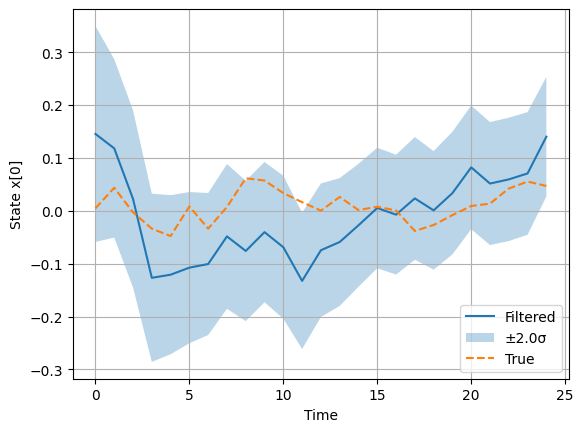

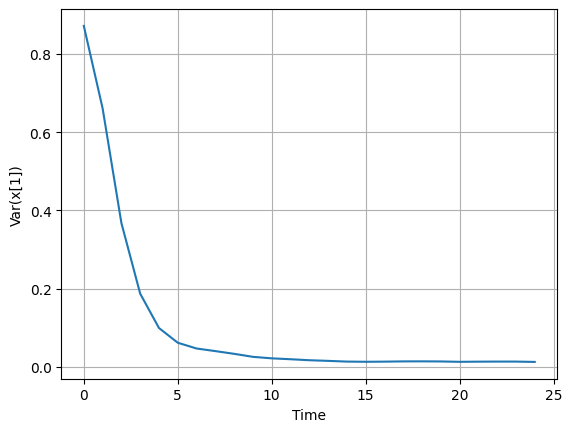

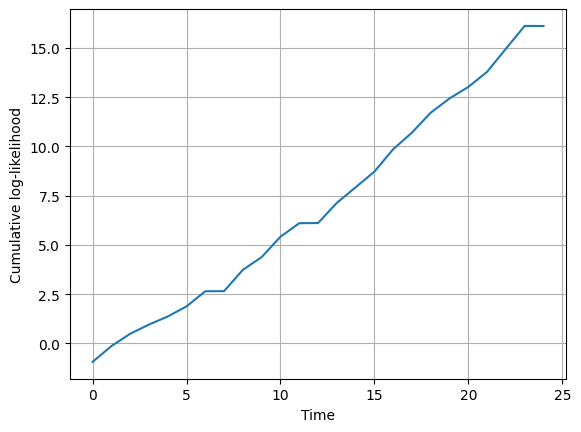

RMSE total: 0.15278458236348139


In [7]:
pf.plot_state(dim=0, X_true=X_true)
pf.plot_variance(dim=1)
pf.plot_loglikelihood()

print("RMSE total:", pf.rmse_total(X_true))

### Lokta-Volterra model

In [ ]:

model_lv = LotkaVolterraSSM(
    alpha=1.5,
    beta=1.0,
    delta=1.0,
    gamma=3.0,
    dt=0.1,
    m0=np.array([1.0, 0.5]),
    P0=0.5 * np.eye(2),
    Sigma=0.1 * np.eye(2),
    Gamma=0.5 * np.eye(2),
    H=np.array([[1.0, 0.0],[0.0, 0.0]])
)

res_lv = run_experiment(model_lv, T=25, L_r = 5, pf_particles=5000)


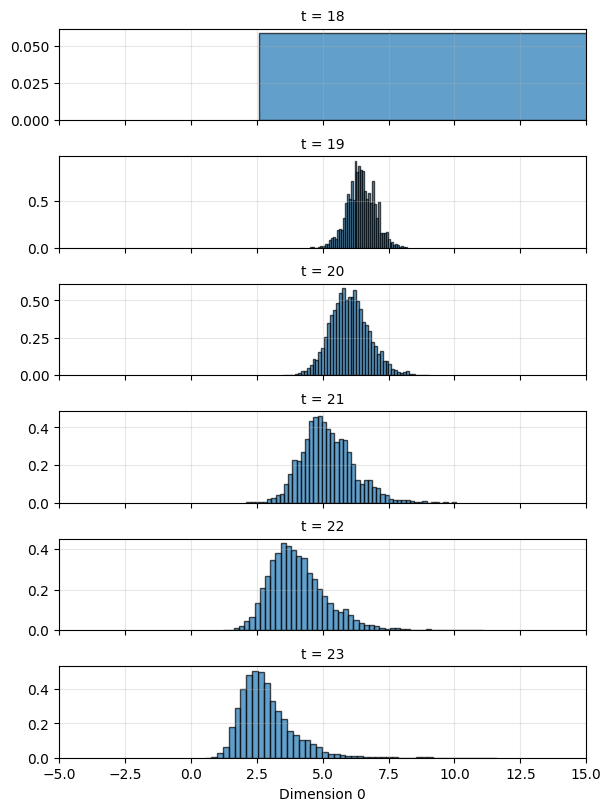

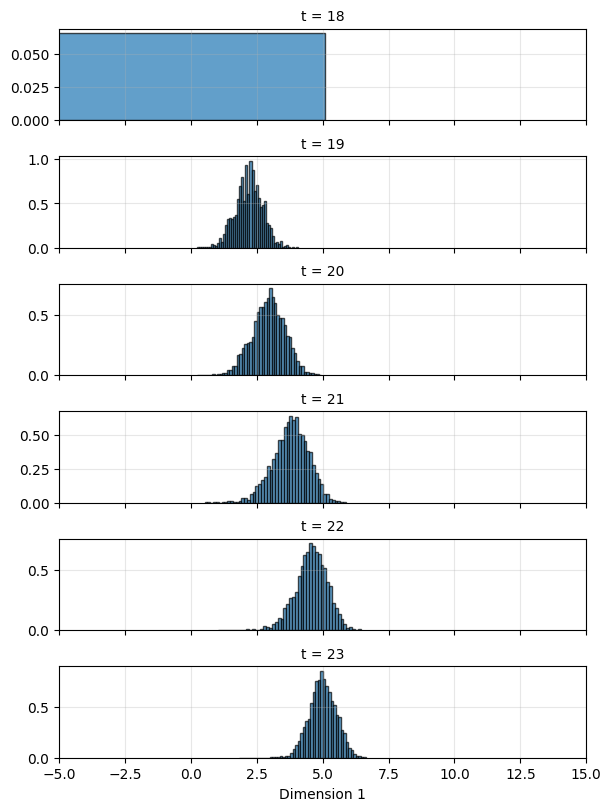

In [10]:

T_v = 18
dim = 0
lims = (-5, 15)

particles = np.array(res_lv['results']['PF']['history']['particles'])

fig, axes = plt.subplots(
    nrows=6, ncols=1,
    figsize=(6, 8),
    sharex=True,
    constrained_layout=True
)

for i, ax in enumerate(axes):
    ax.hist(
        particles[T_v + i, :, dim],
        bins=50,
        density=True,
        alpha=0.7,
        edgecolor="black"
    )
    ax.set_title(f"t = {T_v + i}", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlim(lims)
axes[-1].set_xlabel(f"Dimension {dim}")

plt.show()

########################


dim = 1

particles = np.array(res_lv['results']['PF']['history']['particles'])

fig, axes = plt.subplots(
    nrows=6, ncols=1,
    figsize=(6, 8),
    sharex=True,
    constrained_layout=True
)

for i, ax in enumerate(axes):
    ax.hist(
        particles[T_v + i, :, dim],
        bins=50,
        density=True,
        alpha=0.7,
        edgecolor="black"
    )
    ax.set_title(f"t = {T_v + i}", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlim(lims)
axes[-1].set_xlabel(f"Dimension {dim}")

plt.show()

del T_v, dim, lims, particles, fig, axes

### Lorenz 63' model

In [13]:
model_l63 = Lorenz63SSM(
    sigma=10.0,
    rho=28.0,
    beta=8/3,
    dt=0.0285,
    m0=np.array([1.0, 1.0, 1.0]),
    P0=0.01 * np.eye(3),
    Sigma=0.1 * np.eye(3),
    Gamma=0.1 * np.eye(3), 
    H=np.array([[0.0, 0.0, 0.0],[1.0, 0.0, 1.0],[0.0, 0.0, 1.0]])
)

res_l63 = run_experiment(model_l63, T=30, L_r = 5, pf_particles=25000)


KF  | RMSE: 0.25554 | logL: -62.80899 | time: 0.005s
UKF | RMSE: 0.25691 | logL: -62.81106 | time: 0.014s
PF  | RMSE: 0.24540 | logL: -63.00237 | time: 117.632s
BF  | RMSE: 0.24848 | logL: -63.25831 | time: 6.766s


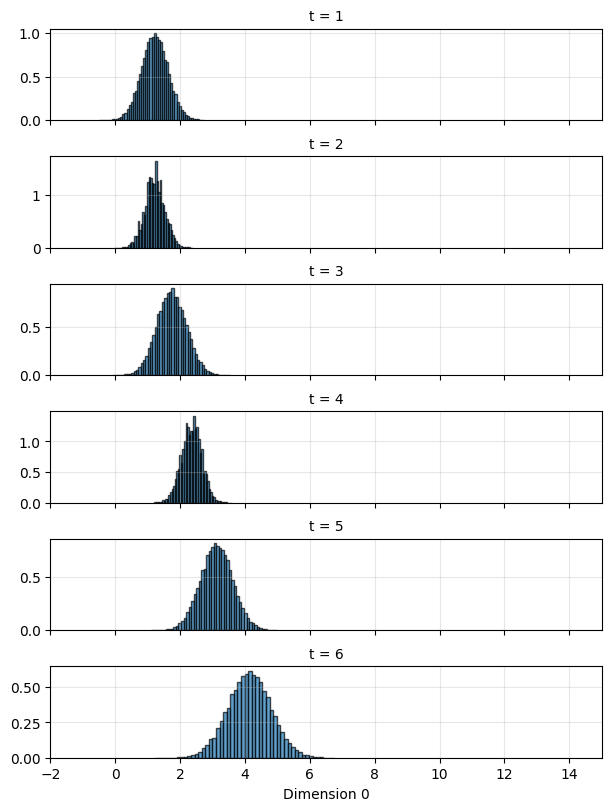

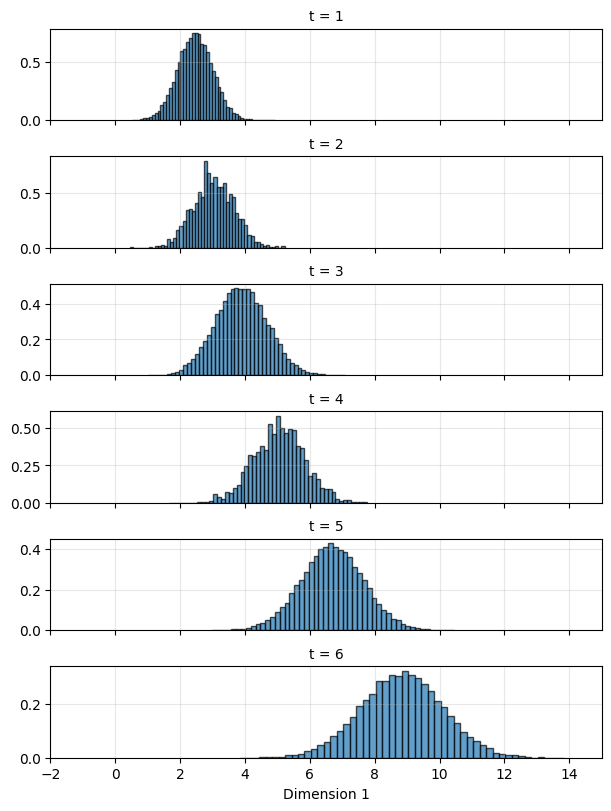

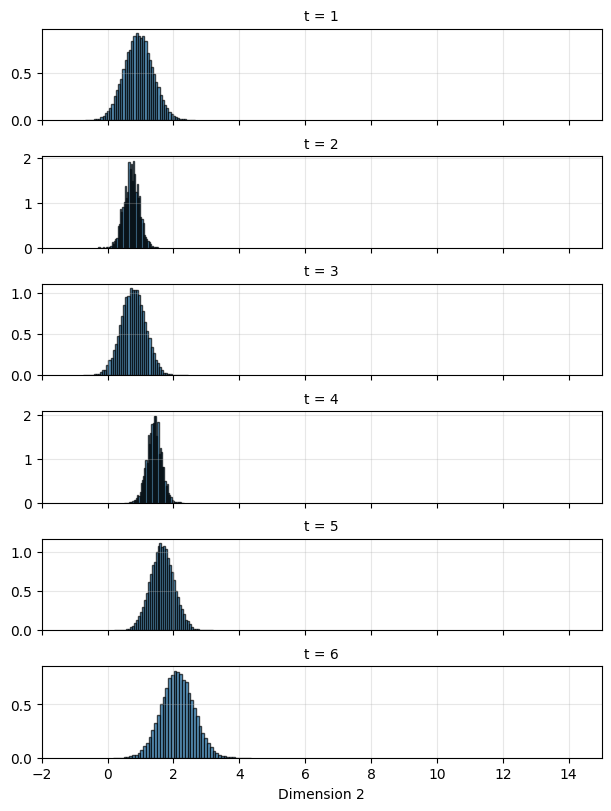

In [14]:

T_v = 1
dim = 0
lims = (-2, 15)

particles = np.array(res_l63['results']['PF']['history']['particles'])

fig, axes = plt.subplots(
    nrows=6, ncols=1,
    figsize=(6, 8),
    sharex=True,
    constrained_layout=True
)

for i, ax in enumerate(axes):
    ax.hist(
        particles[T_v + i, :, dim],
        bins=50,
        density=True,
        alpha=0.7,
        edgecolor="black"
    )
    ax.set_title(f"t = {T_v + i}", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlim(lims)
axes[-1].set_xlabel(f"Dimension {dim}")

plt.show()

########################
dim = 1

fig, axes = plt.subplots(
    nrows=6, ncols=1,
    figsize=(6, 8),
    sharex=True,
    constrained_layout=True
)

for i, ax in enumerate(axes):
    ax.hist(
        particles[T_v + i, :, dim],
        bins=50,
        density=True,
        alpha=0.7,
        edgecolor="black"
    )
    ax.set_title(f"t = {T_v + i}", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlim(lims)
axes[-1].set_xlabel(f"Dimension {dim}")

plt.show()


########################
dim = 2

fig, axes = plt.subplots(
    nrows=6, ncols=1,
    figsize=(6, 8),
    sharex=True,
    constrained_layout=True
)

for i, ax in enumerate(axes):
    ax.hist(
        particles[T_v + i, :, dim],
        bins=50,
        density=True,
        alpha=0.7,
        edgecolor="black"
    )
    ax.set_title(f"t = {T_v + i}", fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlim(lims)
axes[-1].set_xlabel(f"Dimension {dim}")

plt.show()

del T_v, dim, lims, particles, fig, axes

# Numerical experiments

## Drift

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from scipy.linalg import sqrtm
from scipy.stats import wasserstein_distance

np.random.seed(42)  # reproducibility


Drift metrics (mean-based)

In [20]:
def euclidean_drift(m_gauss, m_pf):
    """
    Euclidean drift between Gaussian filter and PF means.
    """
    return np.linalg.norm(m_gauss - m_pf)


def mahalanobis_drift(m_gauss, m_pf, P_pf):
    """
    Mahalanobis drift using PF covariance as reference metric.
    """
    diff = m_gauss - m_pf
    try:
        invP = np.linalg.inv(P_pf)
    except np.linalg.LinAlgError:
        invP = np.linalg.pinv(P_pf)

    return np.sqrt(diff.T @ invP @ diff)


Closed-form Wasserstein distance (Gaussian vs Gaussian)

In [21]:
def wasserstein_2_gaussian(m1, P1, m2, P2):
    """
    Closed-form Wasserstein-2 distance between two Gaussian distributions.
    """
    mean_term = np.linalg.norm(m1 - m2)**2

    # symmetric sqrt
    sqrtP2 = sqrtm(P2)
    middle = sqrtm(sqrtP2 @ P1 @ sqrtP2)

    trace_term = np.trace(P1 + P2 - 2 * middle)

    return np.sqrt(np.real(mean_term + trace_term))


In [22]:
def wasserstein_1_particles_vs_gaussian(particles, m_gauss):
    """
    Approximate W1 using marginal 1D Wasserstein per dimension.
    """
    d = particles.shape[1]
    w1 = 0.0

    for i in range(d):
        w1 += wasserstein_distance(
            particles[:, i],
            np.random.normal(m_gauss[i], 1e-6, size=len(particles))
        )

    return w1


Single-run drift experiment

In [23]:
def single_drift_run(
    model,
    T=500,
    N_pf_gt=20000,   # high fidelity PF
    N_pf_ref=5000    # regular PF for comparison
):
    """
    Run one simulation and compute drift metrics.
    """

    # Simulate data
    X_true, Y = model.simulate(T)

    # High-fidelity PF (ground truth)
    pf_gt = ParticleFilter(model, N=N_pf_gt)
    pf_gt.filter(Y)

    # UKF
    ukf = UnscentedKalmanFilter(model)
    ukf.filter(Y)

    # Extract histories
    m_pf = np.array(pf_gt.history_m)
    P_pf = np.array(pf_gt.history_P)

    m_ukf = np.array(ukf.history_m)
    P_ukf = np.array(ukf.history_P)

    drift_euc = []
    drift_maha = []
    drift_w2 = []

    for k in range(len(m_pf)):
        d_e = euclidean_drift(m_ukf[k], m_pf[k])
        d_m = mahalanobis_drift(m_ukf[k], m_pf[k], P_pf[k])
        d_w2 = wasserstein_2_gaussian(
            m_ukf[k], P_ukf[k],
            m_pf[k], P_pf[k]
        )

        drift_euc.append(d_e)
        drift_maha.append(d_m)
        drift_w2.append(d_w2)

    return {
        "drift_euclidean": np.array(drift_euc),
        "drift_mahalanobis": np.array(drift_maha),
        "drift_w2": np.array(drift_w2),
        "X_true": X_true,
        "ukf": ukf,
        "pf_gt": pf_gt
    }


Drift time detection

In [24]:
def drift_time(drift_norm, threshold=3.0):
    """
    Return first time index where normalized drift exceeds threshold.
    """
    idx = np.where(drift_norm > threshold)[0]
    if len(idx) == 0:
        return np.nan
    return idx[0]


Monte Carlo experiment

In [25]:
def monte_carlo_drift(
    model,
    R=10,
    T=500,
    threshold=3.0
):
    """
    Monte Carlo experiment for drift statistics.
    """

    drift_times = []
    max_w2 = []
    cumulative_w2 = []

    for r in range(R):
        print(f"Run {r+1}/{R}")

        out = single_drift_run(model, T=T)

        tau = drift_time(
            out["drift_mahalanobis"],
            threshold=threshold
        )

        drift_times.append(tau)
        max_w2.append(np.max(out["drift_w2"]))
        cumulative_w2.append(np.sum(out["drift_w2"]))

    return {
        "drift_times": np.array(drift_times),
        "max_w2": np.array(max_w2),
        "cumulative_w2": np.array(cumulative_w2)
    }


Example execution (Lotka–Volterra)

In [27]:
model = LotkaVolterraSSM(
    dt=0.02,
    Sigma=1e-4 * np.eye(2),
    Gamma=5e-2 * np.eye(2)
)

results = monte_carlo_drift(
    model,
    R=5,
    T=30,
    threshold=3.0
)

print("Median drift time:",
      np.nanmedian(results["drift_times"]))

print("Probability of drift:",
      np.mean(~np.isnan(results["drift_times"])))

print("Median max W2:",
      np.median(results["max_w2"]))


Run 1/5
Run 2/5
Run 3/5
Run 4/5
Run 5/5
Median drift time: nan
Probability of drift: 0.0
Median max W2: 0.06920854103629734


C:\Users\carlo\AppData\Local\Temp\ipykernel_12804\3851982743.py:15: RuntimeWarning: All-NaN slice encountered
  np.nanmedian(results["drift_times"]))


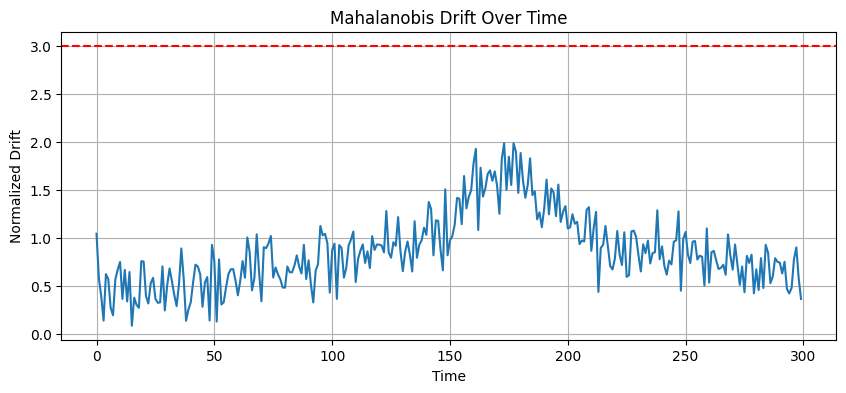

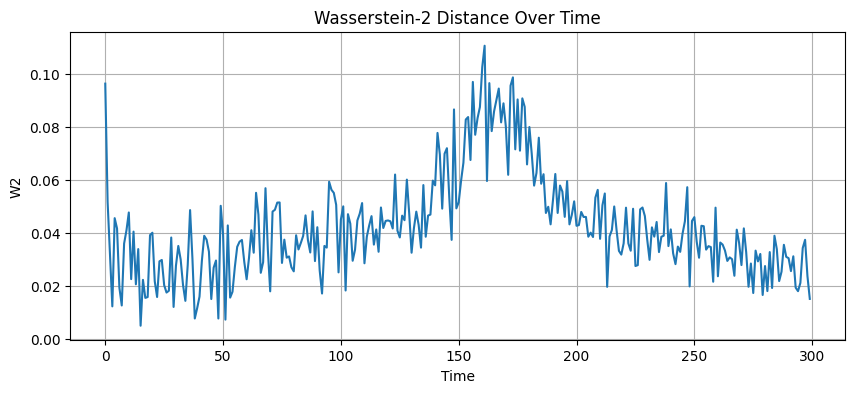

In [31]:
out = single_drift_run(model, T=300)

plt.figure(figsize=(10,4))
plt.plot(out["drift_mahalanobis"])
plt.axhline(3.0, color="red", linestyle="--")
plt.title("Mahalanobis Drift Over Time")
plt.xlabel("Time")
plt.ylabel("Normalized Drift")
plt.grid(True)
plt.show()


plt.figure(figsize=(10,4))
plt.plot(out["drift_w2"])
plt.title("Wasserstein-2 Distance Over Time")
plt.xlabel("Time")
plt.ylabel("W2")
plt.grid(True)
plt.show()


## How to choose the number of particles and the checkpoints?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import itertools
import pandas as pd

np.random.seed(123)


In [ ]:
def evaluate_configuration(
    model,
    L,
    N,
    Y,
    X_true,
    R=5
):
    """
    Evaluate one (L, N) configuration over R Monte Carlo runs.
    Returns aggregated metrics.
    """

    rmse_list = []
    mae_list = []
    ll_list = []
    time_list = []

    for r in range(R):

        # reinitialize model prior for each repetition
        filter_instance = UKF_PF(
            model,
            L=L,
            N=N
        )

        start = time.perf_counter()
        filter_instance.filter(Y)
        end = time.perf_counter()

        elapsed = end - start

        rmse_val = filter_instance.rmse_total(X_true)
        mae_val = np.mean(filter_instance.mae(X_true))
        ll_val = filter_instance.get_loglikelihood()[-1]

        rmse_list.append(rmse_val)
        mae_list.append(mae_val)
        ll_list.append(ll_val)
        time_list.append(elapsed)

    rmse_mean = np.mean(rmse_list)
    rmse_var = np.var(rmse_list)
    mae_mean = np.mean(mae_list)
    ll_mean = np.mean(ll_list)
    time_mean = np.mean(time_list)

    efficiency = rmse_mean / time_mean

    return {
        "L": L,
        "N": N,
        "RMSE": rmse_mean,
        "RMSE_var": rmse_var,
        "MAE": mae_mean,
        "LogLik": ll_mean,
        "Time": time_mean,
        "Efficiency": efficiency
    }


In [ ]:
def hyperparameter_grid_experiment(
    model,
    T=300,
    L_values=[5,10,20,40],
    N_values=[500,1000,5000,10000],
    R=3
):
    """
    Full grid experiment.
    """

    # Simulate dataset ONCE (same dataset for fairness)
    X_true, Y = model.simulate(T)

    results = []

    for L, N in itertools.product(L_values, N_values):

        print(f"Evaluating L={L}, N={N}")

        metrics = evaluate_configuration(
            model=model,
            L=L,
            N=N,
            Y=Y,
            X_true=X_true,
            R=R
        )

        results.append(metrics)

    df = pd.DataFrame(results)

    return df


In [ ]:
model = LotkaVolterraSSM(
    dt=0.02,
    Sigma=1e-4 * np.eye(2),
    Gamma=5e-2 * np.eye(2)
)

df_results = hyperparameter_grid_experiment(
    model,
    T=300,
    R=3
)

print(df_results)


In [ ]:
def plot_heatmap(df, metric_name):

    pivot = df.pivot(index="L", columns="N", values=metric_name)

    plt.figure(figsize=(6,5))
    plt.imshow(pivot, aspect="auto")
    plt.colorbar(label=metric_name)

    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)

    plt.xlabel("N (Particles)")
    plt.ylabel("L (Checkpoint interval)")
    plt.title(f"{metric_name} Heatmap")
    plt.show()


plot_heatmap(df_results, "RMSE")
plot_heatmap(df_results, "Time")
plot_heatmap(df_results, "Efficiency")


In [ ]:
def plot_pareto(df):

    plt.figure(figsize=(6,5))

    for _, row in df.iterrows():
        plt.scatter(row["Time"], row["RMSE"])
        plt.text(row["Time"], row["RMSE"],
                 f"L={row['L']},N={row['N']}",
                 fontsize=8)

    plt.xlabel("Time")
    plt.ylabel("RMSE")
    plt.title("Pareto Frontier: Accuracy vs Cost")
    plt.grid(True)
    plt.show()


plot_pareto(df_results)


In [ ]:
best_idx = df_results["Efficiency"].idxmin()
best_config = df_results.loc[best_idx]

print("Recommended configuration:")
print(best_config)


## Comparison proposed vs classic

In [ ]:
from scipy.stats import norm
from scipy.stats import wilcoxon
import pandas as pd

def crps_gaussian(mu, sigma, x):
    """
    Closed-form CRPS for 1D Gaussian.
    """
    z = (x - mu) / sigma
    return sigma * (z * (2 * norm.cdf(z) - 1) +
                    2 * norm.pdf(z) -
                    1 / np.sqrt(np.pi))


In [ ]:
def crps_multivariate(mean, cov, x_true):
    """
    Average marginal CRPS across dimensions.
    """
    d = len(mean)
    score = 0.0
    for i in range(d):
        sigma = np.sqrt(cov[i, i])
        score += crps_gaussian(mean[i], sigma, x_true[i])
    return score / d


In [ ]:
def run_multiple_experiments_enhanced(
    model,
    T,
    n_iter=30,
    L_r=10,
    pf_particles=5000,
    print_table=True,
    plot_box=True
):
    """
    Enhanced method comparison experiment.
    """

    methods = ["KF", "UKF", "PF", "BF"]
    metrics = ["rmse", "mae", "logL", "crps", "time", "ess", "ess_per_sec"]

    stats = {
        m: {k: [] for k in metrics}
        for m in methods
    }

    for i in tqdm(range(n_iter), desc="Monte Carlo", unit="run"):

        results = run_experiment(
            model,
            T,
            L_r=L_r,
            pf_particles=pf_particles,
            print_results=False
        )

        X_true = results["X_true"]
        final_state = X_true[-1]

        for m in methods:

            res = results["results"][m]

            mean = res["filtering_mean"]
            cov = res["filtering_cov"]

            rmse_val = np.sqrt(np.mean((mean - final_state)**2))
            mae_val = np.mean(np.abs(mean - final_state))
            logL_val = res["logL"]

            crps_val = crps_multivariate(mean, cov, final_state)

            time_val = results[m]["time"]

            if m == "PF":
                ess_val = np.mean(results[m]["ess"])
            else:
                ess_val = np.nan

            ess_per_sec = ess_val / time_val if not np.isnan(ess_val) else np.nan

            stats[m]["rmse"].append(rmse_val)
            stats[m]["mae"].append(mae_val)
            stats[m]["logL"].append(logL_val)
            stats[m]["crps"].append(crps_val)
            stats[m]["time"].append(time_val)
            stats[m]["ess"].append(ess_val)
            stats[m]["ess_per_sec"].append(ess_per_sec)

    # Convert to numpy arrays
    for m in methods:
        for k in metrics:
            stats[m][k] = np.array(stats[m][k])

    # ======================================================
    # Summary table
    # ======================================================
    if print_table:

        print("\nStatistical summary (mean ± std)\n")

        header = (
            f"{'Method':<6} | {'RMSE':<15} | {'CRPS':<15} | "
            f"{'logL':<15} | {'Time':<10}"
        )
        print(header)
        print("-" * len(header))

        for m in methods:
            print(
                f"{m:<6} | "
                f"{stats[m]['rmse'].mean():.4f} ± {stats[m]['rmse'].std():.4f} | "
                f"{stats[m]['crps'].mean():.4f} ± {stats[m]['crps'].std():.4f} | "
                f"{stats[m]['logL'].mean():.2f} ± {stats[m]['logL'].std():.2f} | "
                f"{stats[m]['time'].mean():.3f}"
            )

    # ======================================================
    # Boxplots
    # ======================================================
    if plot_box:
        for metric in ["rmse", "crps", "time"]:
            plt.figure(figsize=(6,4))
            data = [stats[m][metric] for m in methods]
            plt.boxplot(data, tick_labels=methods)
            plt.title(metric.upper())
            plt.grid(alpha=0.3)
            plt.show()

    return stats


In [ ]:
from scipy.stats import t

def bayesian_method_comparison(stats, metric="rmse", baseline="BF"):
    """
    Fully Bayesian comparison between methods.
    Computes posterior probability that BF is better.
    """

    methods = list(stats.keys())

    print(f"\nBayesian comparison using metric: {metric.upper()}\n")

    for m in methods:

        if m == baseline:
            continue

        # Paired differences
        delta = stats[baseline][metric] - stats[m][metric]

        n = len(delta)
        mean_delta = np.mean(delta)
        std_delta = np.std(delta, ddof=1)

        # Posterior for mean under normal model with unknown variance
        # Using Student-t posterior

        se = std_delta / np.sqrt(n)
        df = n - 1

        # Probability that BF is better (delta < 0)
        prob = t.cdf(0, df=df, loc=mean_delta, scale=se)

        # 95% credible interval
        ci_low = mean_delta - t.ppf(0.975, df) * se
        ci_high = mean_delta + t.ppf(0.975, df) * se

        print(f"{baseline} vs {m}:")
        print(f"  Mean difference = {mean_delta:.6f}")
        print(f"  95% credible interval = [{ci_low:.6f}, {ci_high:.6f}]")
        print(f"  P({baseline} better than {m}) = {prob:.4f}\n")


In [ ]:
def bayesian_ranking(stats, metric="rmse"):

    methods = list(stats.keys())
    scores = {m: 0.0 for m in methods}

    for m1 in methods:
        for m2 in methods:
            if m1 == m2:
                continue

            delta = stats[m1][metric] - stats[m2][metric]
            prob = np.mean(delta < 0)
            scores[m1] += prob

    print("\nBayesian ranking (higher = better):")
    for m in sorted(scores, key=scores.get, reverse=True):
        print(m, "score =", scores[m])


In [ ]:
stats_lv = run_multiple_experiments_enhanced(
    model=model_lv,
    T=100,
    n_iter=30,
    L_r=4,
    pf_particles=5000
)

bayesian_method_comparison(stats_lv, metric="rmse")
bayesian_method_comparison(stats_lv, metric="crps")

bayesian_ranking(stats_lv, metric="rmse")
